In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
#Step 1: Import the required modules
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA

from datetime import timedelta

from prophet import Prophet

from sklearn import preprocessing

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz,DecisionTreeRegressor
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE



In [5]:
#Step 2: Generate the dataset
data=pd.read_csv('/content/drive/MyDrive/Sales.csv')

In [6]:
data

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units)
0,2023-01-09,1,10613,442,0,0.00,15
1,2023-09-11,32,320011,2377,0,0.00,1
2,2023-07-24,18,180107,7476,2,687.94,15
3,2024-12-09,42,422609,7983,4,1031.04,29
4,2023-05-22,40,401005,7268,6,684.50,849
...,...,...,...,...,...,...,...
1242783,2024-01-01,64,640607,1016,0,0.00,4
1242784,2023-11-06,34,340906,7181,0,0.00,11
1242785,2025-02-17,62,620014,5928,1,387.07,33
1242786,2024-08-19,7,71525,7860,0,0.00,2


In [7]:
data.dtypes

,0
Date,object
Department,int64
Category,int64
Brand,int64
Sales (Units),int64
Sales (Amount),float64
Inventory (Units),int64


In [8]:
data.isnull().sum()

,0
Date,0
Department,0
Category,0
Brand,0
Sales (Units),0
Sales (Amount),0
Inventory (Units),0


In [9]:
data['Department'].nunique()


56

In [10]:
data['Brand'].nunique()

2323

In [11]:
data['Category'].nunique()

2763

In [12]:
data['Date'].nunique()

126

In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)
data.describe()

,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units)
count,1242788.00,1242788.00,1242788.00,1242788.00,1242788.00,1242788.00
mean,23.96,240024.62,3949.67,4.15,3697.91,79.32
std,17.12,171152.66,2698.67,17.76,32858.05,263.41
min,1.00,10001.00,4.00,-43.00,-251721.64,-4958.00
25%,11.00,110108.00,1145.00,0.00,0.00,5.00
50%,21.00,210103.00,3838.00,1.00,178.44,18.00
75%,36.00,361818.00,6542.00,3.00,1612.70,65.00
max,66.00,660504.00,8219.00,3262.00,13197240.68,17871.00


In [14]:
int((data['Sales (Units)']<0).sum())

4105

In [15]:
int((data['Sales (Amount)']<0).sum())

5747

In [16]:
int((data['Inventory (Units)']<0).sum())

23410

In [17]:
data['Date'] =pd.to_datetime(data['Date'])

In [18]:
data= data.sort_values('Date')

In [19]:
data.groupby(['Department','Category','Brand']).size().sort_values(ascending=False)


Department  Category  Brand
1           10001     3525     126
9           90220     836      126
                      2844     126
            90222     944      126
                      2129     126
                              ... 
6           60105     8186       1
31          310204    5993       1
41          411007    878        1
9           90536     7133       1
12          120206    7888       1
Length: 17680, dtype: int64

In [20]:
data

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units)
38160,2023-01-02,32,320009,1275,1,503.53,0
312659,2023-01-02,66,660003,2489,1,31.68,64
635912,2023-01-02,18,180016,78,9,524.90,139
312764,2023-01-02,29,290710,6897,3,1911.20,3
635806,2023-01-02,14,140525,3911,1,447.41,0
...,...,...,...,...,...,...,...
319465,2025-05-26,47,470215,78,0,0.00,18
319454,2025-05-26,26,260206,6807,6,360.38,51
1087328,2025-05-26,40,400102,8061,3,516.93,20
319221,2025-05-26,2,20347,7765,0,0.00,3


**Assumptions:**
There are no product returns from customers.

The company does not issue any refunds after a sale.

The sales system does not allow the sale of a product when its stock is zero or insufficient.



In [21]:
# Remove rows with negative values in the target columns.
data_t = data[
    (data['Sales (Units)'] >= 0) &
    (data['Sales (Amount)'] >= 0) &
    (data['Inventory (Units)'] >= 0)
]


In [22]:
data_t['Product_Id'] = ('P_' +
    data_t['Department'].astype(str) + '|' +
    data_t['Category'].astype(str) + '|' +
    data_t['Brand'].astype(str)
)


In [23]:
data_t

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id
38160,2023-01-02,32,320009,1275,1,503.53,0,P_32|320009|1275
312659,2023-01-02,66,660003,2489,1,31.68,64,P_66|660003|2489
635912,2023-01-02,18,180016,78,9,524.90,139,P_18|180016|78
312764,2023-01-02,29,290710,6897,3,1911.20,3,P_29|290710|6897
635806,2023-01-02,14,140525,3911,1,447.41,0,P_14|140525|3911
...,...,...,...,...,...,...,...,...
319465,2025-05-26,47,470215,78,0,0.00,18,P_47|470215|78
319454,2025-05-26,26,260206,6807,6,360.38,51,P_26|260206|6807
1087328,2025-05-26,40,400102,8061,3,516.93,20,P_40|400102|8061
319221,2025-05-26,2,20347,7765,0,0.00,3,P_2|20347|7765


In [24]:
data_t.groupby('Product_Id').size().sort_values(ascending=False)


,0
Product_Id,
P_10|100701|6347,126
P_9|90529|6758,126
P_9|90529|6098,126
P_9|90528|6760,126
P_9|90512|6760,126
...,...
P_21|210103|7197,1
P_40|400105|5337,1
P_41|410101|690,1


In [25]:
data_t[(data_t['Department']==3) & (data_t['Category']==30103) & (data_t['Brand']==614)]

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id
855690,2023-01-02,3,30103,614,450,503104.65,11392,P_3|30103|614
141320,2023-01-09,3,30103,614,268,295734.14,11581,P_3|30103|614
567067,2023-01-16,3,30103,614,283,313575.25,11475,P_3|30103|614
1122792,2023-01-23,3,30103,614,282,305816.38,11209,P_3|30103|614
910153,2023-01-30,3,30103,614,283,307676.09,11505,P_3|30103|614
...,...,...,...,...,...,...,...,...
1229399,2025-04-28,3,30103,614,468,428696.90,12317,P_3|30103|614
568852,2025-05-05,3,30103,614,329,352932.11,12012,P_3|30103|614
974477,2025-05-12,3,30103,614,522,461302.50,11961,P_3|30103|614
1231892,2025-05-19,3,30103,614,427,412211.87,11854,P_3|30103|614


In [26]:

produits_par_dept = data_t.groupby('Department')['Product_Id'].nunique().rename('Nb_Produits')
ventes_par_dept = data_t.groupby('Department')['Sales (Units)'].sum().rename('Ventes_Total')


classement_departements = (
    pd.concat([produits_par_dept, ventes_par_dept], axis=1)
    .sort_values(by=['Nb_Produits', 'Ventes_Total'], ascending=False)
    .reset_index()
)


classement_departements['Classement'] = classement_departements.index

ordre_depts = classement_departements.set_index('Department')['Classement'].to_dict()

data_t['Classement_Dept'] = data_t['Department'].map(ordre_depts)

data1_trie = data_t.sort_values(by='Classement_Dept').drop(columns='Classement_Dept')



In [27]:
data1_trie

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id
672156,2023-02-13,11,110403,4187,0,0.00,24,P_11|110403|4187
1172327,2024-06-10,11,110127,5676,0,0.00,6,P_11|110127|5676
18608,2023-09-25,11,110404,7497,0,0.00,9,P_11|110404|7497
517267,2025-03-24,11,110119,4144,0,0.00,9,P_11|110119|4144
1201187,2023-02-13,11,110107,7454,0,0.00,1,P_11|110107|7454
...,...,...,...,...,...,...,...,...
577894,2023-05-29,65,650001,7411,0,0.00,1,P_65|650001|7411
925374,2024-01-29,65,650003,7411,0,0.00,1,P_65|650003|7411
895468,2024-01-29,65,650002,7411,0,0.00,1,P_65|650002|7411
803176,2024-09-09,65,650001,7411,0,0.00,1,P_65|650001|7411


In [28]:
def is_difficult_series(group):
    sales = group['Sales (Units)']
    return (
         len(sales) < 104 or
         sales.std() == 0   or
         #sales.autocorr(lag=1) < 0.3 or
         (sales == 0).sum() / len(sales) > 0.6
    )

produits_difficiles = (
    data_t.groupby(['Department', 'Category', 'Brand'])
    .filter(is_difficult_series)
)


In [29]:
data1 = (
    data_t.groupby(['Department', 'Category', 'Brand'])
    .filter(lambda g: not is_difficult_series(g))
)


In [30]:
data1

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
635912,2023-01-02,18,180016,78,9,524.90,139,P_18|180016|78,6
312764,2023-01-02,29,290710,6897,3,1911.20,3,P_29|290710|6897,13
1090510,2023-01-02,26,260307,2166,4,5513.79,48,P_26|260307|2166,22
312872,2023-01-02,20,200611,5038,7,2860.86,48,P_20|200611|5038,11
635940,2023-01-02,3,30207,6935,2,2351.72,96,P_3|30207|6935,14
...,...,...,...,...,...,...,...,...,...
80629,2025-05-26,46,460001,5977,5,84.51,0,P_46|460001|5977,42
319799,2025-05-26,2,20121,6516,0,0.00,18,P_2|20121|6516,3
319505,2025-05-26,15,150025,575,0,0.00,7,P_15|150025|575,34
319221,2025-05-26,2,20347,7765,0,0.00,3,P_2|20347|7765,3


In [31]:
data1.groupby('Product_Id').size().sort_values(ascending=False)

,0
Product_Id,
P_9|90222|5875,126
P_11|110102|1228,126
P_9|90681|3792,126
P_9|90222|4490,126
P_11|110102|5676,126
...,...
P_47|470402|1016,104
P_45|450401|7797,104
P_46|460001|6251,104


In [32]:
data1['Department'].nunique()

53

In [33]:

departments_data1 = set(data_t['Department'].unique())


departments_sans_difficiles = set(data1['Department'].unique())


departments_exclus = departments_data1 - departments_sans_difficiles

print("Départements exclus car tous leurs produits sont difficiles :")
print(departments_exclus)


Départements exclus car tous leurs produits sont difficiles :
{np.int64(24), np.int64(65), np.int64(63)}


In [34]:
data1

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
635912,2023-01-02,18,180016,78,9,524.90,139,P_18|180016|78,6
312764,2023-01-02,29,290710,6897,3,1911.20,3,P_29|290710|6897,13
1090510,2023-01-02,26,260307,2166,4,5513.79,48,P_26|260307|2166,22
312872,2023-01-02,20,200611,5038,7,2860.86,48,P_20|200611|5038,11
635940,2023-01-02,3,30207,6935,2,2351.72,96,P_3|30207|6935,14
...,...,...,...,...,...,...,...,...,...
80629,2025-05-26,46,460001,5977,5,84.51,0,P_46|460001|5977,42
319799,2025-05-26,2,20121,6516,0,0.00,18,P_2|20121|6516,3
319505,2025-05-26,15,150025,575,0,0.00,7,P_15|150025|575,34
319221,2025-05-26,2,20347,7765,0,0.00,3,P_2|20347|7765,3


In [35]:
stats_data1 = data1.groupby('Product_Id')['Sales (Units)'].describe()


In [36]:
stats_data1.head(50)

,count,mean,std,min,25%,50%,75%,max
Product_Id,,,,,,,,
P_10|100701|3678,123.00,4.29,4.55,0.00,2.00,3.00,5.00,29.00
P_10|100701|5123,123.00,2.71,3.37,0.00,1.00,2.00,3.00,21.00
P_10|100701|6347,126.00,7.38,5.76,0.00,3.00,5.00,11.00,30.00
P_10|100701|952,125.00,3.91,3.82,0.00,1.00,3.00,5.00,21.00
P_10|100702|2478,112.00,1.33,1.57,0.00,0.00,1.00,2.00,8.00
P_10|100702|6347,116.00,8.86,5.50,1.00,5.00,8.00,11.00,26.00
P_10|100703|6347,108.00,1.44,1.42,0.00,0.00,1.00,2.00,6.00
P_11|110101|5676,115.00,0.71,1.09,0.00,0.00,0.00,1.00,6.00
P_11|110102|1228,126.00,4.40,4.51,0.00,2.00,3.00,6.00,32.00


In [37]:
data1[(data1['Department']==11)]

,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
9605,2023-01-02,11,110119,6066,15,7133.69,230,P_11|110119|6066,0
638614,2023-01-02,11,110112,3982,1,542.50,0,P_11|110112|3982,0
310054,2023-01-02,11,110119,6476,13,3508.79,137,P_11|110119|6476,0
321486,2023-01-02,11,110108,614,1,430.17,96,P_11|110108|614,0
321763,2023-01-02,11,110404,4187,6,2472.68,83,P_11|110404|4187,0
...,...,...,...,...,...,...,...,...,...
324371,2025-05-26,11,110119,614,12,10609.28,223,P_11|110119|614,0
665474,2025-05-26,11,110107,4303,1,0.01,11,P_11|110107|4303,0
1090214,2025-05-26,11,110104,5333,0,0.00,6,P_11|110104|5333,0
675663,2025-05-26,11,110114,3982,0,0.00,0,P_11|110114|3982,0


Text(0.5, 1.0, 'Total Sales per Week')

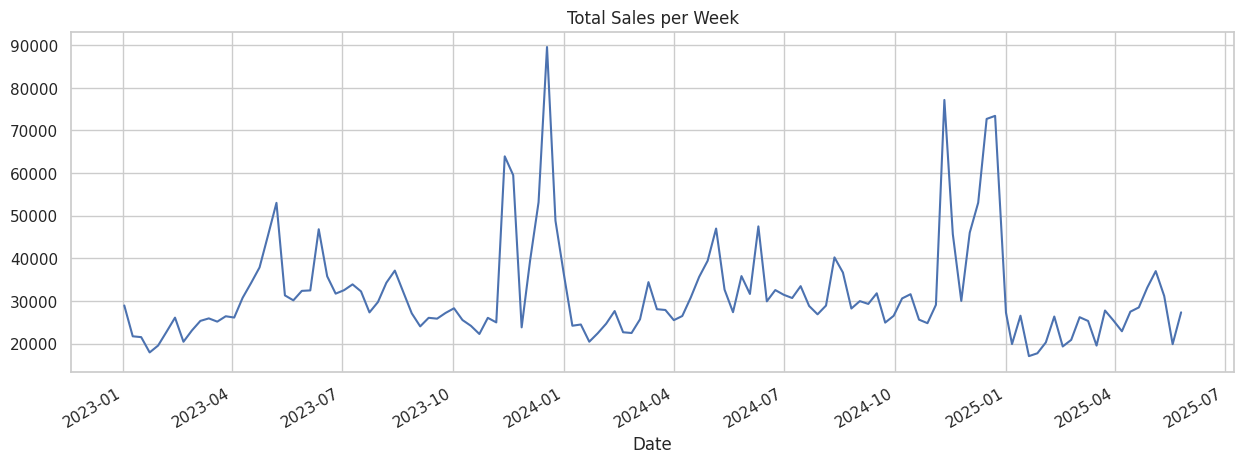

In [38]:
data1.groupby("Date")["Sales (Units)"].sum().plot(figsize=(15, 5))
plt.title("Total Sales per Week")


Text(0.5, 1.0, 'Mean of sales per week')

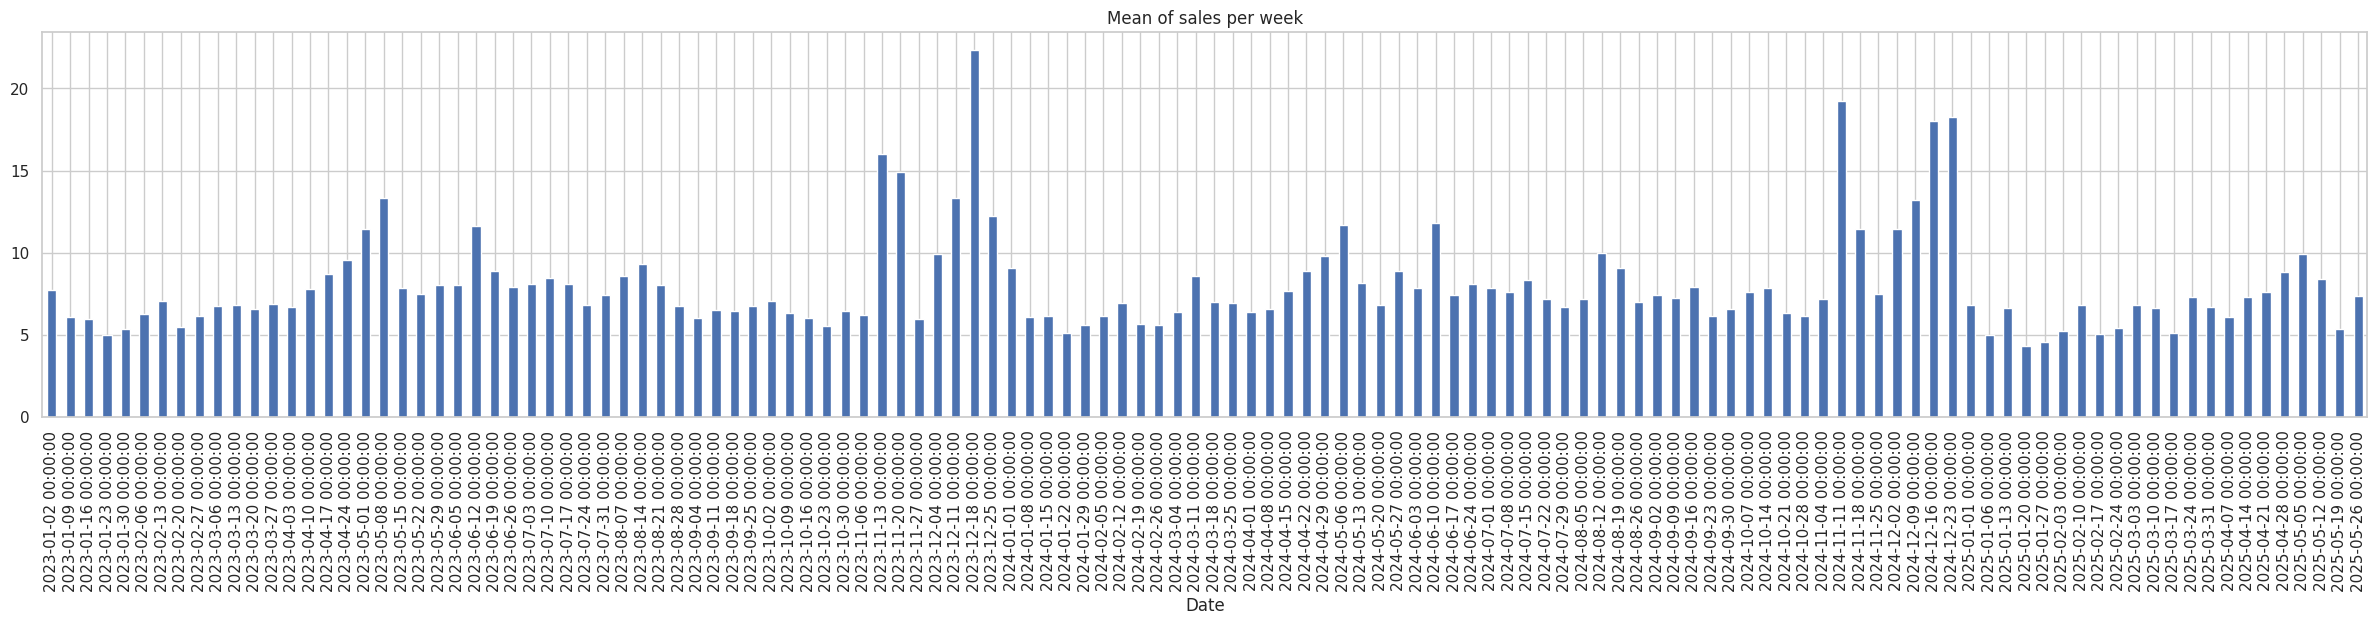

In [39]:
data1.groupby("Date")["Sales (Units)"].mean().plot(kind="bar", figsize=(30, 5))
plt.title("Mean of sales per week")



In [40]:
data1= data1.reset_index()

In [41]:
data1['Date'] =pd.to_datetime(data1['Date'])

In [42]:
data1= data1.sort_values('Date')

In [43]:
data1

,index,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
0,635912,2023-01-02,18,180016,78,9,524.90,139,P_18|180016|78,6
2486,117250,2023-01-02,33,330011,1327,18,7779.86,199,P_33|330011|1327,20
2487,116439,2023-01-02,21,210103,2420,5,2621.73,46,P_21|210103|2420,4
2488,116339,2023-01-02,40,400001,6356,3,2083.62,35,P_40|400001|6356,31
2489,115340,2023-01-02,12,120215,4303,3,1053.63,0,P_12|120215|4303,16
...,...,...,...,...,...,...,...,...,...,...
494322,960561,2025-05-26,12,120201,1179,0,0.00,9,P_12|120201|1179,16
494323,40126,2025-05-26,3,30105,538,18,14434.70,245,P_3|30105|538,14
494324,1029086,2025-05-26,38,380209,4824,1,4995.76,42,P_38|380209|4824,45
494326,1029146,2025-05-26,58,580003,6902,6,1348.28,109,P_58|580003|6902,37


In [44]:
def Graph_sale(Product_Id):
    df = data1[data1['Product_Id'] == Product_Id].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    plt.figure(figsize=(12, 5))
    plt.plot(df['Date'], df['Sales (Units)'], marker='o', label='Sales')
    plt.title(f"Evolution of Weekly Sales - {Product_Id}")
    plt.xlabel("Date")
    plt.ylabel("Sales (Units)")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    print(df['Sales (Units)'].autocorr(1))


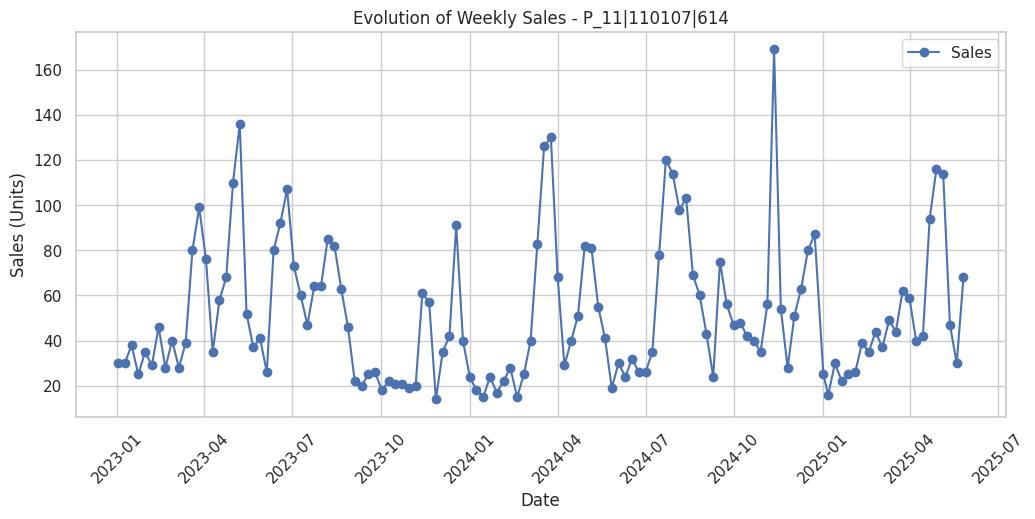

0.5916778836490239


In [45]:
Graph_sale('P_11|110107|614')

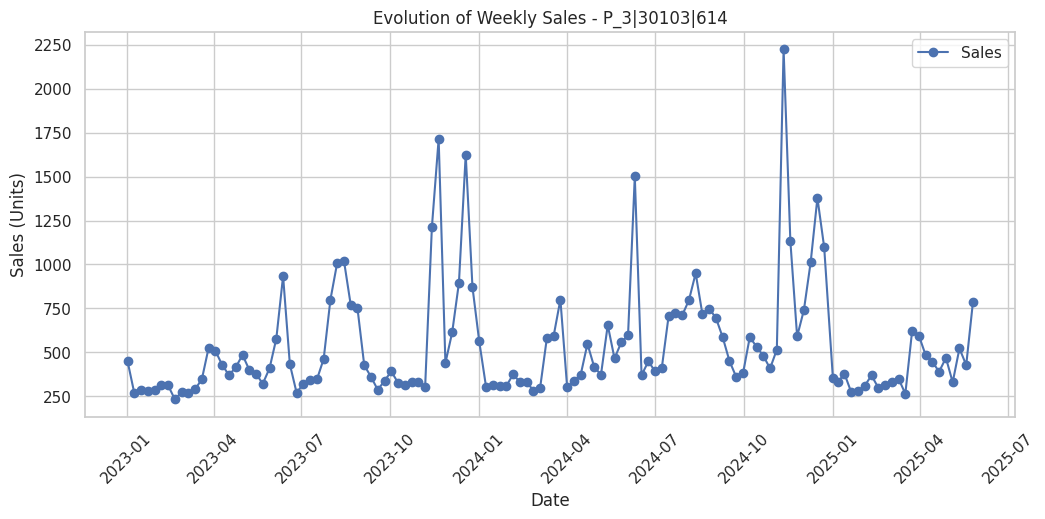

0.4764077671562434


In [46]:
Graph_sale('P_3|30103|614')

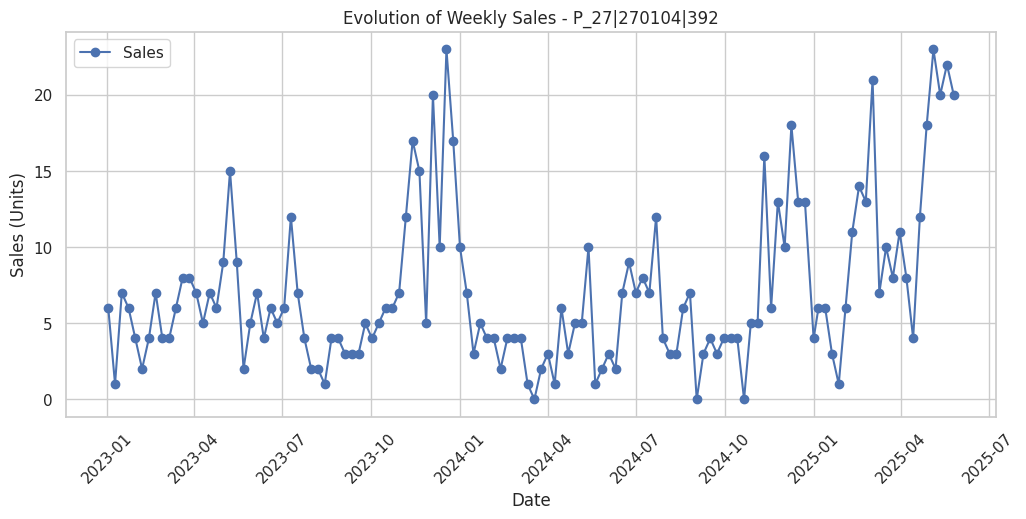

0.6307156221795849


In [47]:
Graph_sale('P_27|270104|392')

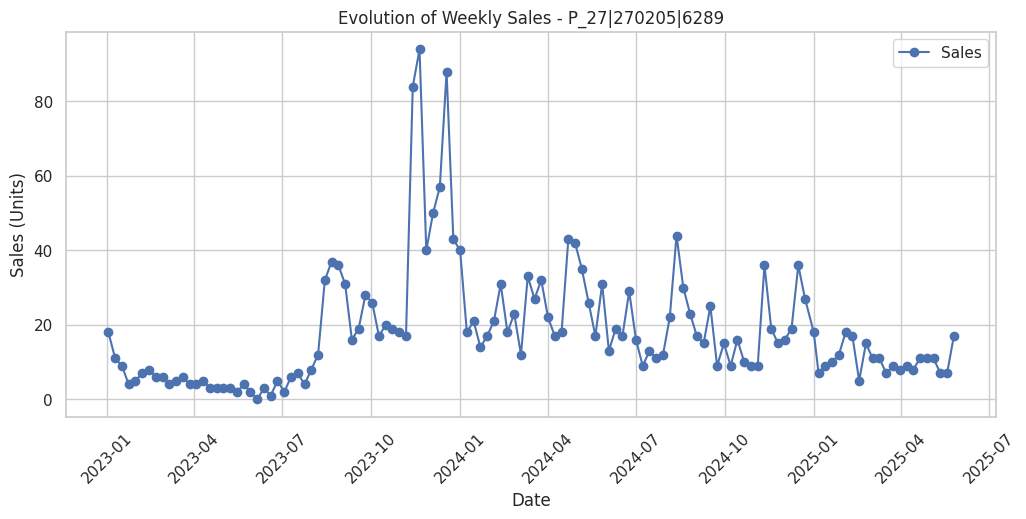

0.7125679640318325


In [48]:
Graph_sale('P_27|270205|6289')

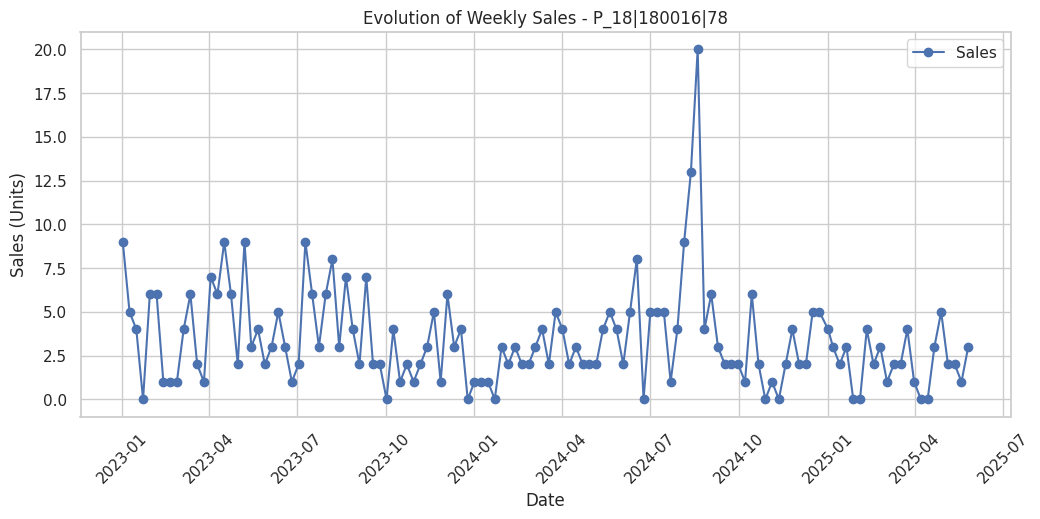

0.35184277161134386


In [49]:
Graph_sale('P_18|180016|78')

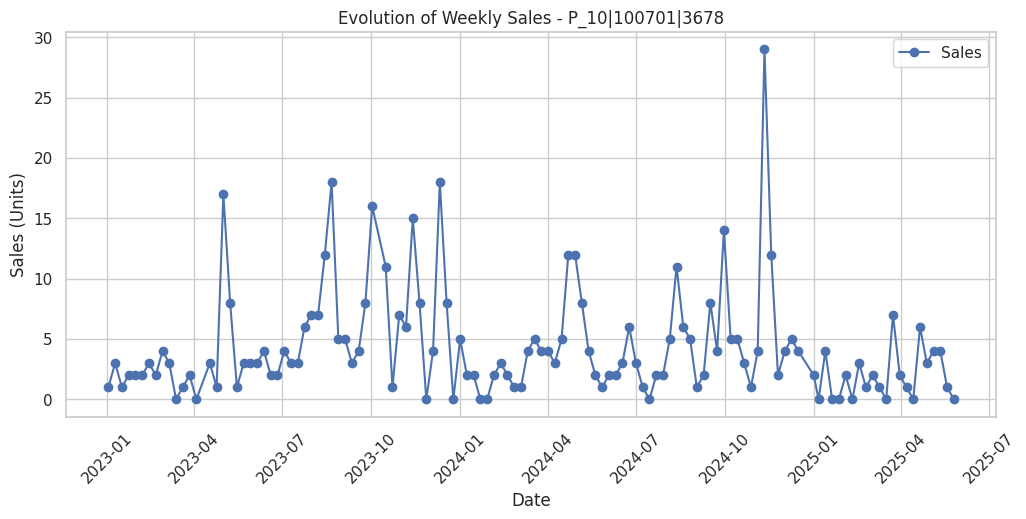

0.3575817911467765


In [50]:
Graph_sale('P_10|100701|3678')

In [73]:
data2= data1[(data1['Department']==3) & (data1['Category']==30103) & (data1['Brand']==614)]

In [74]:
data2

,index,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
3075,855690,2023-01-02,3,30103,614,450,503104.65,11392,P_3|30103|614,14
4687,141320,2023-01-09,3,30103,614,268,295734.14,11581,P_3|30103|614,14
10567,567067,2023-01-16,3,30103,614,283,313575.25,11475,P_3|30103|614,14
12690,1122792,2023-01-23,3,30103,614,282,305816.38,11209,P_3|30103|614,14
15498,910153,2023-01-30,3,30103,614,283,307676.09,11505,P_3|30103|614,14
20828,389781,2023-02-06,3,30103,614,314,342098.11,11162,P_3|30103|614,14
24433,15854,2023-02-13,3,30103,614,311,345948.49,10842,P_3|30103|614,14
28917,891465,2023-02-20,3,30103,614,232,252683.02,10471,P_3|30103|614,14
32545,213650,2023-02-27,3,30103,614,274,300872.89,10174,P_3|30103|614,14
34617,320943,2023-03-06,3,30103,614,266,277313.51,9751,P_3|30103|614,14


In [78]:
data2['Date']= pd.to_datetime(data2['Date'])

In [79]:
data2= data2.sort_values('Date')

In [80]:
data2

,index,Date,Department,Category,Brand,Sales (Units),Sales (Amount),Inventory (Units),Product_Id,Classement_Dept
3075,855690,2023-01-02,3,30103,614,450,503104.65,11392,P_3|30103|614,14
4687,141320,2023-01-09,3,30103,614,268,295734.14,11581,P_3|30103|614,14
10567,567067,2023-01-16,3,30103,614,283,313575.25,11475,P_3|30103|614,14
12690,1122792,2023-01-23,3,30103,614,282,305816.38,11209,P_3|30103|614,14
15498,910153,2023-01-30,3,30103,614,283,307676.09,11505,P_3|30103|614,14
20828,389781,2023-02-06,3,30103,614,314,342098.11,11162,P_3|30103|614,14
24433,15854,2023-02-13,3,30103,614,311,345948.49,10842,P_3|30103|614,14
28917,891465,2023-02-20,3,30103,614,232,252683.02,10471,P_3|30103|614,14
32545,213650,2023-02-27,3,30103,614,274,300872.89,10174,P_3|30103|614,14
34617,320943,2023-03-06,3,30103,614,266,277313.51,9751,P_3|30103|614,14


**ARIMA**


=== Dept=3 | Cat=30103 | Brand=614 ===
MAE  : 240.22
RMSE : 289.68
R²   : -0.0865
MAPE : 54.35%
sMAPE: 44.36%


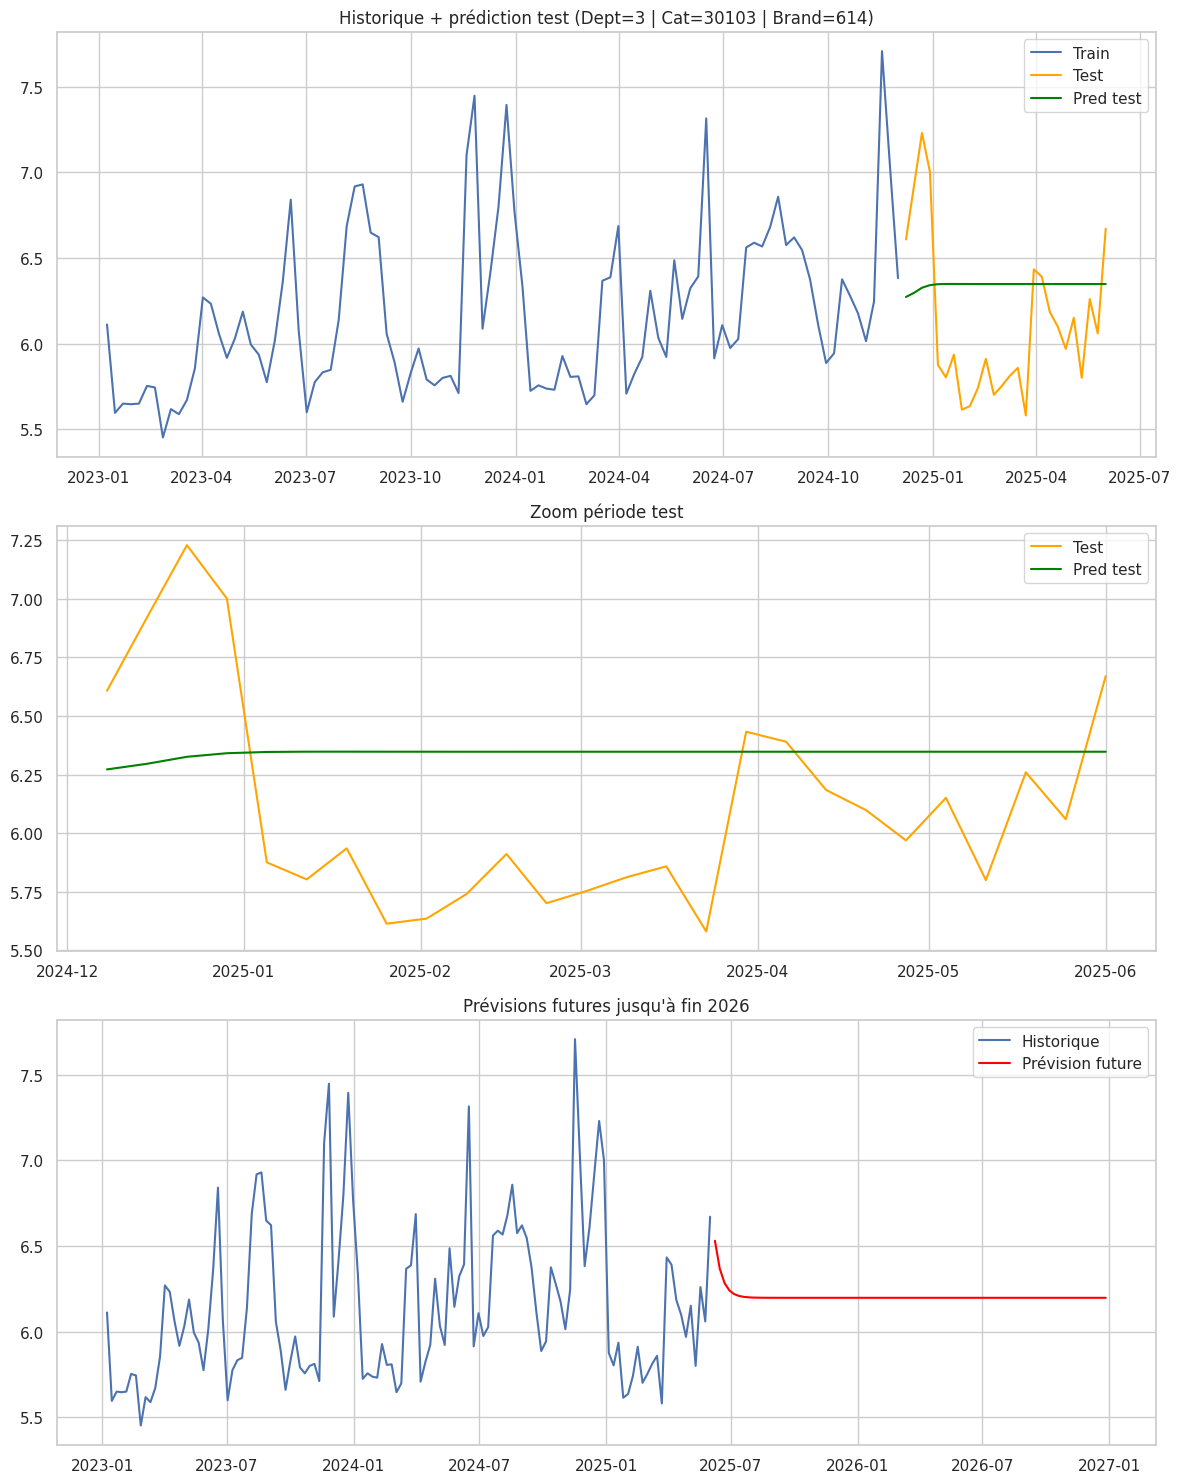

In [81]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def plot_results(train, test, pred_test, forecast_future, product_id):
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))


    axs[0].plot(train.index, train, label="Train")
    axs[0].plot(test.index, test, label="Test", color="orange")
    axs[0].plot(test.index, pred_test, label="Pred test", color="green")
    axs[0].legend()
    axs[0].set_title(f"Historique + prédiction test ({product_id})")


    axs[1].plot(test.index, test, label="Test", color="orange")
    axs[1].plot(test.index, pred_test, label="Pred test", color="green")
    axs[1].legend()
    axs[1].set_title("Zoom période test")


    axs[2].plot(pd.concat([train, test]).index, pd.concat([train, test]), label="Historique")
    axs[2].plot(forecast_future.index, forecast_future, label="Prévision future", color="red")
    axs[2].legend()
    axs[2].set_title("Prévisions futures jusqu'à fin 2026")

    plt.tight_layout()
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def run_arima_for_product(df, dept, cat, brand):
    product_id = f"Dept={dept} | Cat={cat} | Brand={brand}"

    prod_df = df[(df["Department"] == dept) &
                 (df["Category"] == cat) &
                 (df["Brand"] == brand)].copy()

    prod_df["Date"] = pd.to_datetime(prod_df["Date"])
    prod_df = prod_df.sort_values("Date").set_index("Date")
    prod_df = prod_df.resample("W")["Sales (Units)"].sum()

    y = np.log1p(prod_df)

    split_idx = int(len(y) * 0.8)
    train, test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = ARIMA(train, order=(2,1,2))
    model_fit = model.fit()
    pred_test = model_fit.forecast(steps=len(test))

    # Transformation inverse
    y_test_actual = np.expm1(test)
    y_test_pred = np.expm1(pred_test)

    # Évaluation
    mae_val = mean_absolute_error(y_test_actual, y_test_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
    r2_val = r2_score(y_test_actual, y_test_pred)
    mape_val = mean_absolute_percentage_error(y_test_actual, y_test_pred) * 100
    smape_val = smape(y_test_actual, y_test_pred)

    print(f"\n=== {product_id} ===")
    print(f"MAE  : {mae_val:.2f}")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"R²   : {r2_val:.4f}")
    print(f"MAPE : {mape_val:.2f}%")
    print(f"sMAPE: {smape_val:.2f}%")

    model_full = ARIMA(y, order=(2,1,2))
    model_full_fit = model_full.fit()

    last_date = y.index.max()
    future_weeks = pd.date_range(last_date + pd.Timedelta(weeks=1), "2026-12-31", freq="W")
    forecast_future = pd.Series(model_full_fit.forecast(steps=len(future_weeks)), index=future_weeks)

    plot_results(train, test, pred_test, forecast_future, product_id)

    return pred_test, forecast_future



pred_test, forecast_future = run_arima_for_product(
    data1,
    dept=3,
    cat=30103	,
    brand=614
)

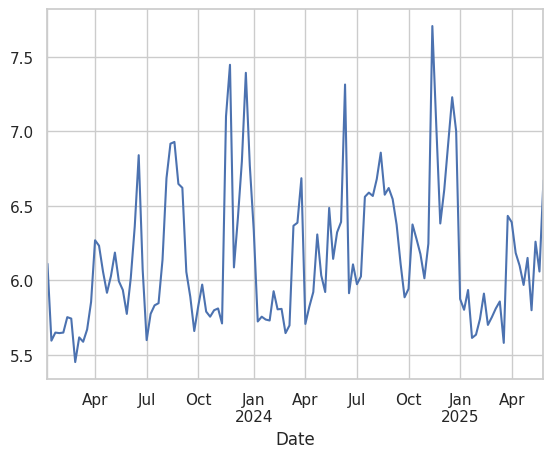

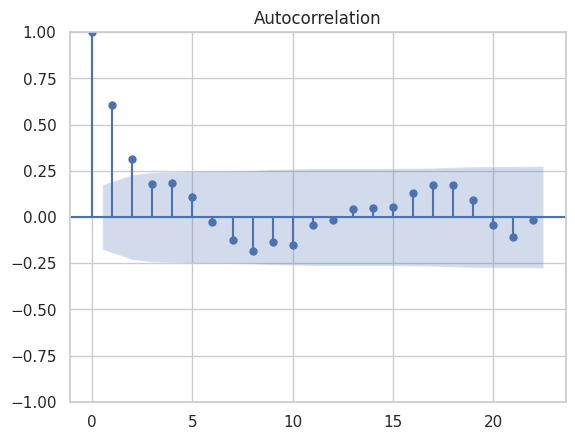

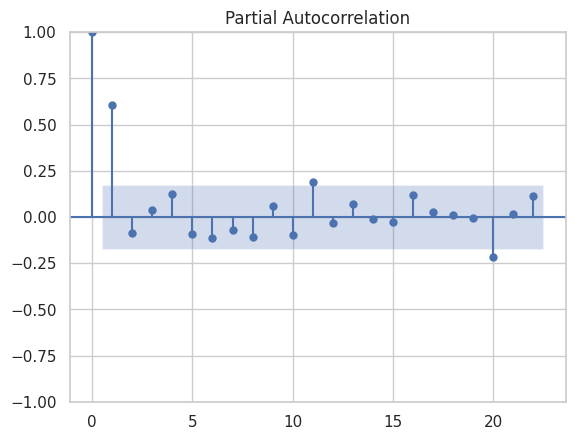

In [82]:

prod_df = data1[(data1["Department"] == 3) &
                 (data1["Category"] == 30103	) &
                 (data1["Brand"] == 614)].copy()

prod_df["Date"] = pd.to_datetime(prod_df["Date"])
prod_df = prod_df.sort_values("Date").set_index("Date")
prod_df = prod_df.resample("W")["Sales (Units)"].sum()

# Apply log-transform
y = np.log1p(prod_df)

y.plot()
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(y); plot_pacf(y)
plt.show()

**SARIMA**

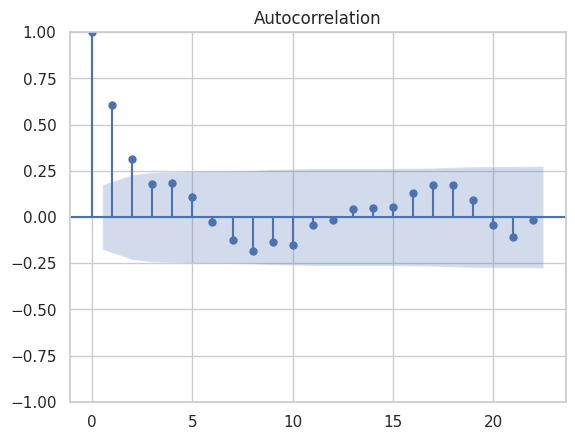

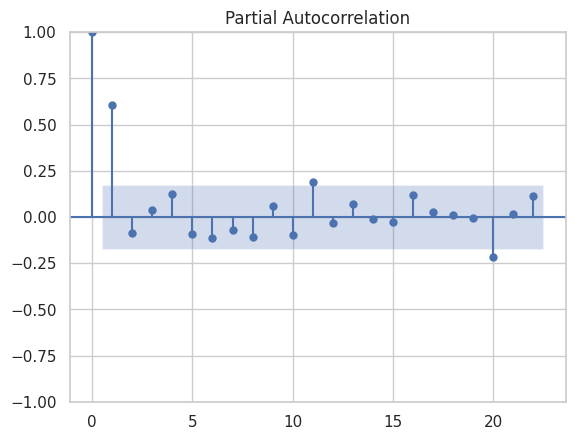


=== Dept=3 | Cat=30103 | Brand=614 ===
MAE  : 97.20
RMSE : 141.11
R²   : 0.7422
MAPE : 17.61%
sMAPE: 18.21%


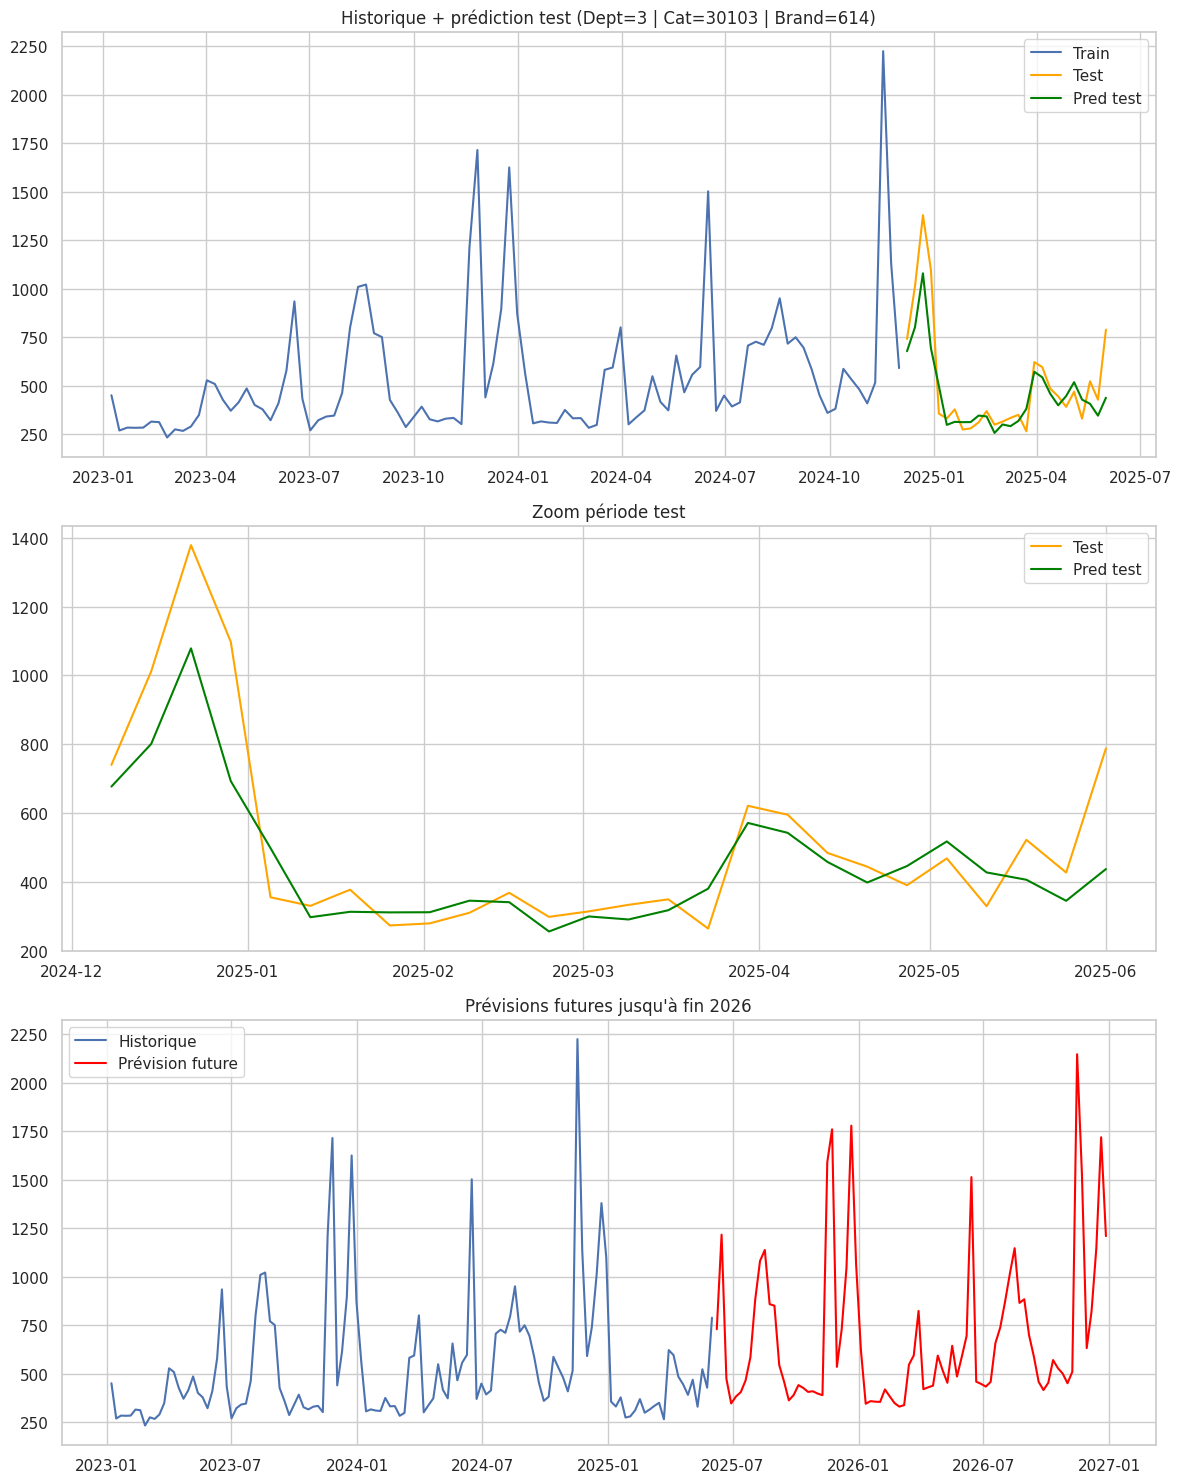

In [83]:



def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def plot_results(train, test, pred_test, forecast_future, product_id):
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))

    axs[0].plot(train.index, np.expm1(train), label="Train")
    axs[0].plot(test.index, np.expm1(test), label="Test", color="orange")
    axs[0].plot(test.index, np.expm1(pred_test).clip(0), label="Pred test", color="green")
    axs[0].legend()
    axs[0].set_title(f"Historique + prédiction test ({product_id})")

    axs[1].plot(test.index, np.expm1(test), label="Test", color="orange")
    axs[1].plot(test.index, np.expm1(pred_test).clip(0), label="Pred test", color="green")
    axs[1].legend()
    axs[1].set_title("Zoom période test")

    axs[2].plot(pd.concat([train, test]).index, np.expm1(pd.concat([train, test])), label="Historique")
    axs[2].plot(forecast_future.index, np.expm1(forecast_future).clip(0), label="Prévision future", color="red")
    axs[2].legend()
    axs[2].set_title("Prévisions futures jusqu'à fin 2026")

    plt.tight_layout()
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def run_sarima_for_product(df, dept, cat, brand, seasonal_period=52, epsilon=1e-3):
    product_id = f"Dept={dept} | Cat={cat} | Brand={brand}"

    prod_df = df[(df["Department"] == dept) &
                 (df["Category"] == cat) &
                 (df["Brand"] == brand)].copy()

    prod_df["Date"] = pd.to_datetime(prod_df["Date"])
    prod_df = prod_df.sort_values("Date").set_index("Date")
    prod_df = prod_df.resample("W")["Sales (Units)"].sum()

    y = np.log1p(prod_df)

    # ACF/PACF
    plot_acf(y)
    plot_pacf(y)
    plt.show()

    # Split train/test (80/20)
    split_idx = int(len(y) * 0.8)
    train, test = y.iloc[:split_idx], y.iloc[split_idx:]

    # SARIMAX
    model = SARIMAX(train, order=(2,0,1), seasonal_order=(2,0,1,seasonal_period))
    model_fit = model.fit(disp=False)
    pred_test = model_fit.get_forecast(steps=len(test)).predicted_mean

    # Transformation inverse
    y_test_actual = np.expm1(test) + epsilon
    y_test_pred = np.expm1(pred_test).clip(0) + epsilon

    # Évaluation
    mae_val = mean_absolute_error(y_test_actual, y_test_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
    r2_val = r2_score(y_test_actual, y_test_pred)
    mape_val = mean_absolute_percentage_error(y_test_actual, y_test_pred) * 100
    smape_val = smape(y_test_actual, y_test_pred)

    print(f"\n=== {product_id} ===")
    print(f"MAE  : {mae_val:.2f}")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"R²   : {r2_val:.4f}")
    print(f"MAPE : {mape_val:.2f}%")
    print(f"sMAPE: {smape_val:.2f}%")

    # Prévisions futures
    model_full = SARIMAX(y, order=(2,1,2), seasonal_order=(1,1,1,seasonal_period))
    model_full_fit = model_full.fit(disp=False)

    last_date = y.index.max()
    future_weeks = pd.date_range(last_date + pd.Timedelta(weeks=1), "2026-12-31", freq="W")
    forecast_future = pd.Series(model_full_fit.get_forecast(steps=len(future_weeks)).predicted_mean,
                                index=future_weeks)
    forecast_future = forecast_future.clip(0)

    plot_results(train, test, pred_test, forecast_future, product_id)

    return pred_test, forecast_future


pred_test, forecast_future = run_sarima_for_product(
    data1,
    dept=3,
    cat=30103	,
    brand=614
)

**SARIMAX**

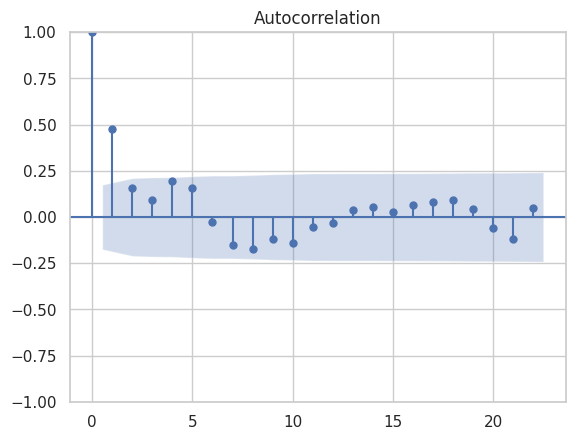

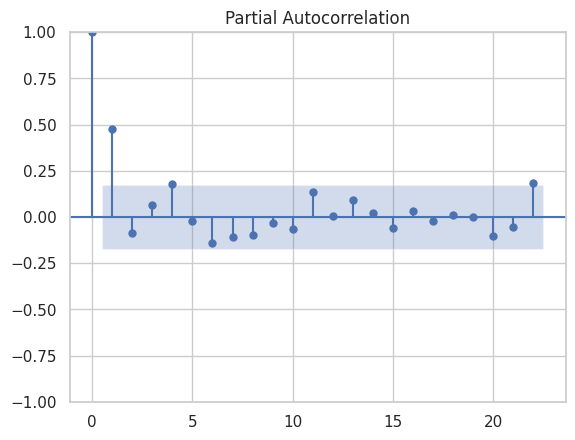


=== Dept=3 | Cat=30103 | Brand=614 ===
MAE : 157.53
RMSE: 173.54
R²  : 0.6101
MAPE : 40.68%
sMAPE: 32.10%


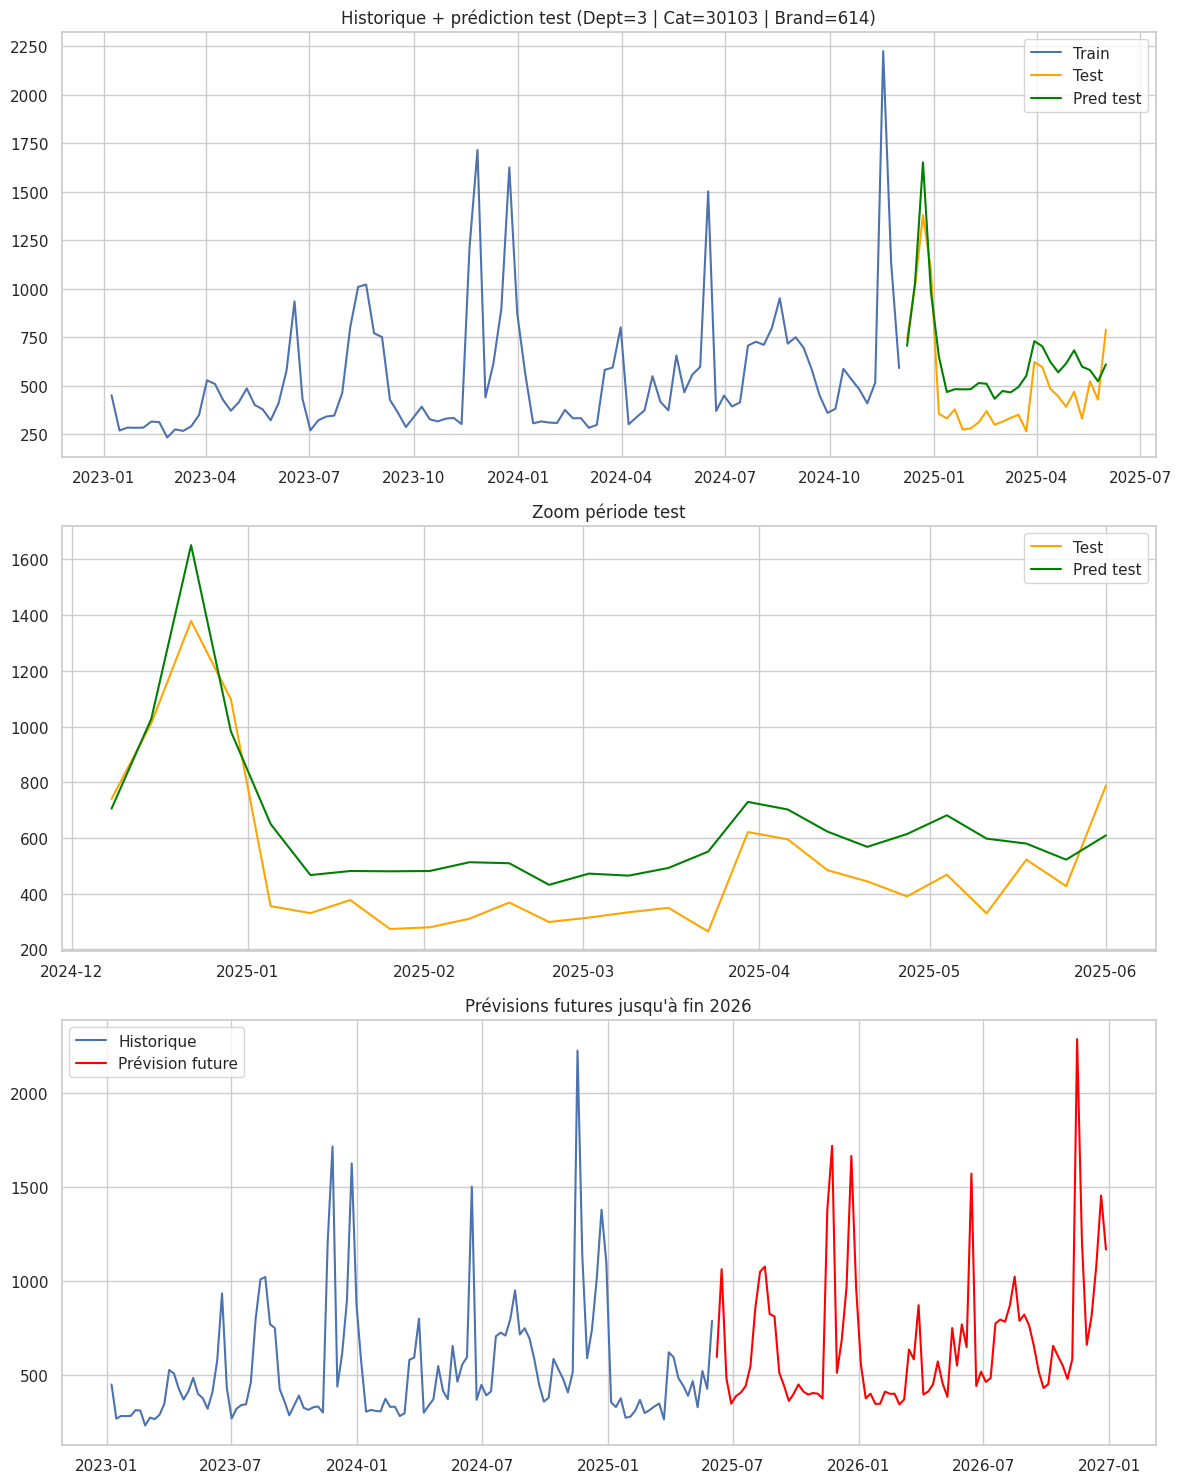

In [84]:



def smape(y_true, y_pred):
    """Calcul du symmetric MAPE"""
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def plot_results(train, test, pred_test, forecast_future, product_id):
    """Affichage des résultats"""
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))

    axs[0].plot(train.index, train, label="Train")
    axs[0].plot(test.index, test, label="Test", color="orange")
    axs[0].plot(test.index, pred_test, label="Pred test", color="green")
    axs[0].legend()
    axs[0].set_title(f"Historique + prédiction test ({product_id})")

    axs[1].plot(test.index, test, label="Test", color="orange")
    axs[1].plot(test.index, pred_test, label="Pred test", color="green")
    axs[1].legend()
    axs[1].set_title("Zoom période test")

    axs[2].plot(pd.concat([train, test]).index, pd.concat([train, test]), label="Historique")
    axs[2].plot(forecast_future.index, forecast_future, label="Prévision future", color="red")
    axs[2].legend()
    axs[2].set_title("Prévisions futures jusqu'à fin 2026")

    plt.tight_layout()
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_sarimax_product(df, dept, cat, brand, seasonal_period=52):
    product_id = f"Dept={dept} | Cat={cat} | Brand={brand}"

    prod_df = df[(df["Department"]==dept) &
                 (df["Category"]==cat) &
                 (df["Brand"]==brand)].copy()

    prod_df["Date"] = pd.to_datetime(prod_df["Date"])
    prod_df = prod_df.sort_values("Date").set_index("Date")
    prod_df = prod_df.resample("W")["Sales (Units)"].sum()

    y = prod_df
    y = y.clip(lower=0)

    plot_acf(y)
    plot_pacf(y)
    plt.show()

    # Split train/test (80/20)
    split_idx = int(len(y) * 0.8)
    train, test = y.iloc[:split_idx], y.iloc[split_idx:]

    # SARIMAX
    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,seasonal_period))
    model_fit = model.fit(disp=False)

    pred_test = model_fit.get_forecast(steps=len(test)).predicted_mean
    pred_test = pred_test.clip(lower=0)

    # Evaluation
    mape_val = mean_absolute_percentage_error(test, pred_test) * 100
    smape_val = smape(test, pred_test)
    mae_val = mean_absolute_error(test, pred_test)
    rmse_val = np.sqrt(mean_squared_error(test, pred_test))
    r2_val = r2_score(test, pred_test)

    print(f"\n=== {product_id} ===")
    print(f"MAE : {mae_val:.2f}")
    print(f"RMSE: {rmse_val:.2f}")
    print(f"R²  : {r2_val:.4f}")
    print(f"MAPE : {mape_val:.2f}%")
    print(f"sMAPE: {smape_val:.2f}%")

    # Modèle complet pour prévisions futures
    model_full = SARIMAX(y, order=(2,1,2), seasonal_order=(1,1,1,seasonal_period))
    model_full_fit = model_full.fit(disp=False)

    last_date = y.index.max()
    future_weeks = pd.date_range(last_date + pd.Timedelta(weeks=1), "2026-12-31", freq="W")
    forecast_future = pd.Series(model_full_fit.get_forecast(steps=len(future_weeks)).predicted_mean,
                                index=future_weeks)
    forecast_future = forecast_future.clip(lower=0)

    plot_results(train, test, pred_test, forecast_future, product_id)

    return pred_test, forecast_future


pred_test, forecast_future = run_sarimax_product(
    data1,
    dept=3,
    cat=30103	,
    brand=614
)



```
# Ce texte est au format code
```
**Model Prophet**


In [85]:

def prophet_prediction(data1, department, category, brand, n_weeks=84):

    df = data1[
        (data1['Department'] == department) &
        (data1['Category'] == category) &
        (data1['Brand'] == brand)
    ].copy()

    if df.empty:
        print("Aucune donnée trouvée pour ce produit.")
        return None


    df['Date'] = pd.to_datetime(df['Date'])
    df = df.groupby('Date')['Sales (Units)'].sum().reset_index()
    df = df.rename(columns={'Date': 'ds', 'Sales (Units)': 'y'})
    df = df.sort_values('ds')

    if df['y'].sum() == 0 or len(df) < 20:
        print("Pas assez de données valides pour ce produit.")
        return None


    model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    model.fit(df)


    future = model.make_future_dataframe(periods=n_weeks, freq='W')
    forecast = model.predict(future)


    forecast = forecast.rename(columns={'yhat': 'Predicted_Sales'})


    df_merge = df.merge(forecast[['ds', 'Predicted_Sales']], on='ds', how='left')


    plt.figure(figsize=(12,6))
    plt.plot(df_merge['ds'], df_merge['y'], label='Ventes réelles', color='blue')
    plt.plot(forecast['ds'], forecast['Predicted_Sales'], label='Prévisions Prophet', color='orange')
    plt.title(f"Prévision Prophet - Dept: {department}, Cat: {category}, Brand: {brand}")
    plt.xlabel("Date")
    plt.ylabel("Ventes hebdomadaires")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return forecast[['ds', 'Predicted_Sales', 'yhat_lower', 'yhat_upper']]



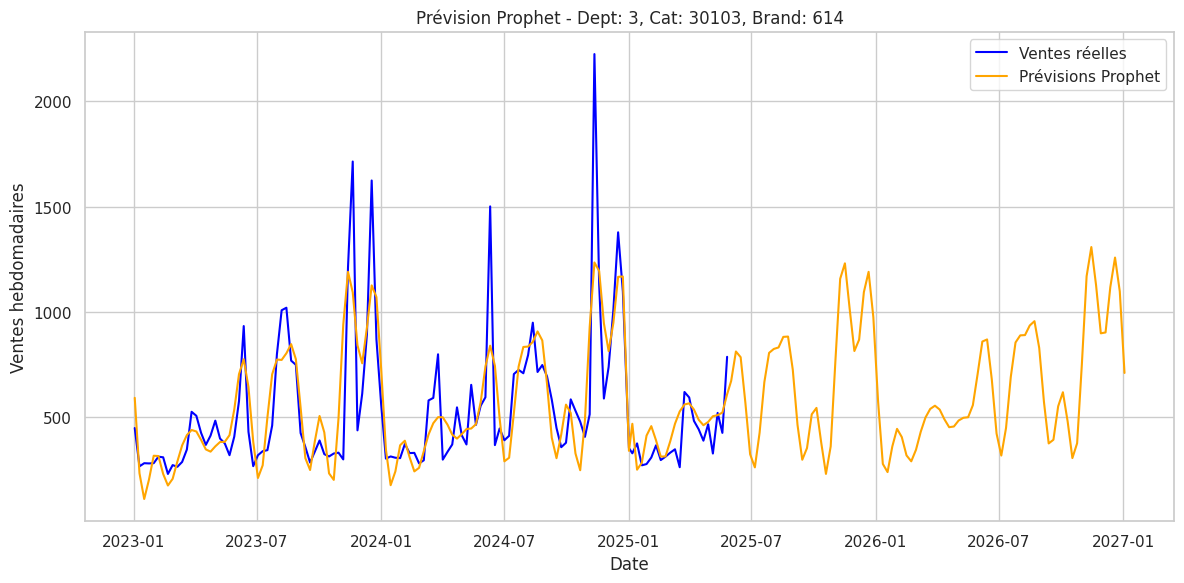


--- Valeurs prédites par semaine ---
Semaine du 2023-01-02 → Prédiction: 593.35 (min: 346.86, max: 844.78)
Semaine du 2023-01-09 → Prédiction: 235.23 (min: 0, max: 493.4)
Semaine du 2023-01-16 → Prédiction: 113.07 (min: 0, max: 361.15)
Semaine du 2023-01-23 → Prédiction: 204.73 (min: 0, max: 449.06)
Semaine du 2023-01-30 → Prédiction: 318.39 (min: 80.9, max: 539.49)
Semaine du 2023-02-06 → Prédiction: 317.07 (min: 62.2, max: 559.72)
Semaine du 2023-02-13 → Prédiction: 231.94 (min: 0, max: 472.38)
Semaine du 2023-02-20 → Prédiction: 177.15 (min: 0, max: 440.86)
Semaine du 2023-02-27 → Prédiction: 208.93 (min: 0, max: 454.31)
Semaine du 2023-03-06 → Prédiction: 291.46 (min: 38.77, max: 547.32)
Semaine du 2023-03-13 → Prédiction: 367.49 (min: 127.4, max: 604.04)
Semaine du 2023-03-20 → Prédiction: 416.42 (min: 179.43, max: 656.02)
Semaine du 2023-03-27 → Prédiction: 440.49 (min: 190.05, max: 692.9)
Semaine du 2023-04-03 → Prédiction: 433.71 (min: 204.42, max: 697.5)
Semaine du 2023-04-10

In [86]:

resultats = prophet_prediction(data1, department=3, category=30103	, brand=614)

if resultats is not None:
    print("\n--- Valeurs prédites par semaine ---")
    for i, row in resultats.iterrows():
        date = row['ds'].strftime('%Y-%m-%d')
        Predicted_Sales = round(row['Predicted_Sales'], 2)
        yhat_lower = round(row['yhat_lower'], 2)
        yhat_upper = round(row['yhat_upper'], 2)
        print(f"Semaine du {date} → Prédiction: {max(Predicted_Sales,0)} (min: {max(yhat_lower,0)}, max: {yhat_upper})")


In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

real_df = data2[['Date', 'Sales (Units)']].copy()
real_df = real_df.rename(columns={'Date': 'ds', 'Sales (Units)': 'y'})

df_merge = real_df.merge(resultats[['ds', 'Predicted_Sales']], on='ds', how='inner')

real_y = df_merge['y'].values
pred_y = df_merge['Predicted_Sales'].values

# MAE / RMSE
mae = mean_absolute_error(real_y, pred_y)
mse = mean_squared_error(real_y, pred_y)
rmse = np.sqrt(mse)

# MAPE / sMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

mape = mean_absolute_percentage_error(real_y, pred_y) * 100
smape_val = smape(real_y, pred_y)

# R²
r2 = r2_score(real_y, pred_y)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape_val:.2f}%")
print(f"R²: {r2:.4f}")


MAE: 128.20
RMSE: 192.39
MAPE: 25.62%
sMAPE: 23.95%
R²: 0.6419



```
# `Ce texte est au format code`

```
# `Model Prophet+ XGBoost
`
```


```



In [99]:
def prophet_prediction(data, department, category, brand, n_weeks=84):

    df = data[
        (data['Department'] == department) &
        (data['Category'] == category) &
        (data['Brand'] == brand)
    ].copy()

    if df.empty:
        print("Aucune donnée trouvée pour ce produit.")
        return None


    df['Date'] = pd.to_datetime(df['Date'])
    df = df.groupby('Date')['Sales (Units)'].sum().reset_index()
    df = df.rename(columns={'Date': 'ds', 'Sales (Units)': 'y'})
    df = df.sort_values('ds')

    if df['y'].sum() == 0 or len(df) < 20:
        print("Pas assez de données valides pour ce produit.")
        return None


    model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    model.fit(df)


    future = model.make_future_dataframe(periods=n_weeks, freq='W')
    forecast = model.predict(future)


    forecast = forecast.rename(columns={'yhat': 'Predicted_Sales'})


    df_merge = df.merge(forecast[['ds', 'Predicted_Sales']], on='ds', how='left')



    return model, forecast, df



In [100]:
model, forecast, df = prophet_prediction(data1, 3,30103		, 614)


if model is not None:
    df_residuals = df.set_index('ds')
    forecast_residuals = forecast.set_index('ds')


df_residuals = df.set_index('ds')
forecast_residuals = forecast.set_index('ds')
residuals = df_residuals['y'] - forecast_residuals['Predicted_Sales']
residuals = residuals.reset_index().rename(columns={0: 'residual'})


forecast = forecast.merge(residuals, on='ds', how='left')
forecast = forecast.merge(df[['ds', 'y']], on='ds', how='left')


In [101]:
from xgboost import XGBRegressor


forecast['dow'] = forecast['ds'].dt.dayofweek
forecast['week'] = forecast['ds'].dt.isocalendar().week
forecast['month'] = forecast['ds'].dt.month

train_data = forecast[forecast['residual'].notna()]
future_data = forecast[forecast['residual'].isna()]


features = ['dow', 'week', 'month']
X_train = train_data[features]
y_train = train_data['residual']

xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)


X_future = future_data[features]
forecast.loc[forecast['residual'].isna(), 'residual_pred'] = xgb_model.predict(X_future)


forecast['corrected_forecast'] = forecast['Predicted_Sales'] + forecast['residual'].fillna(forecast['residual_pred'])



In [102]:
forecast['residual_pred'] = xgb_model.predict(forecast[features])


forecast['corrected_forecast_full'] = forecast['Predicted_Sales'] + forecast['residual_pred']


from sklearn.metrics import r2_score


eval_set = forecast[forecast['y'].notna()]

y_true = eval_set['y'].values
y_pred = eval_set['corrected_forecast_full'].values

# MAE et RMSE
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# MAPE classique
mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

# sMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

smape_val = smape(y_true, y_pred)

# R²
r2 = r2_score(y_true, y_pred)

print(f"Prophet + XGBoost → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | sMAPE: {smape_val:.2f}% | R²: {r2:.4f}")

Prophet + XGBoost → MAE: 73.52 | RMSE: 110.07 | MAPE: 13.73% | sMAPE: 13.33% | R²: 0.8828


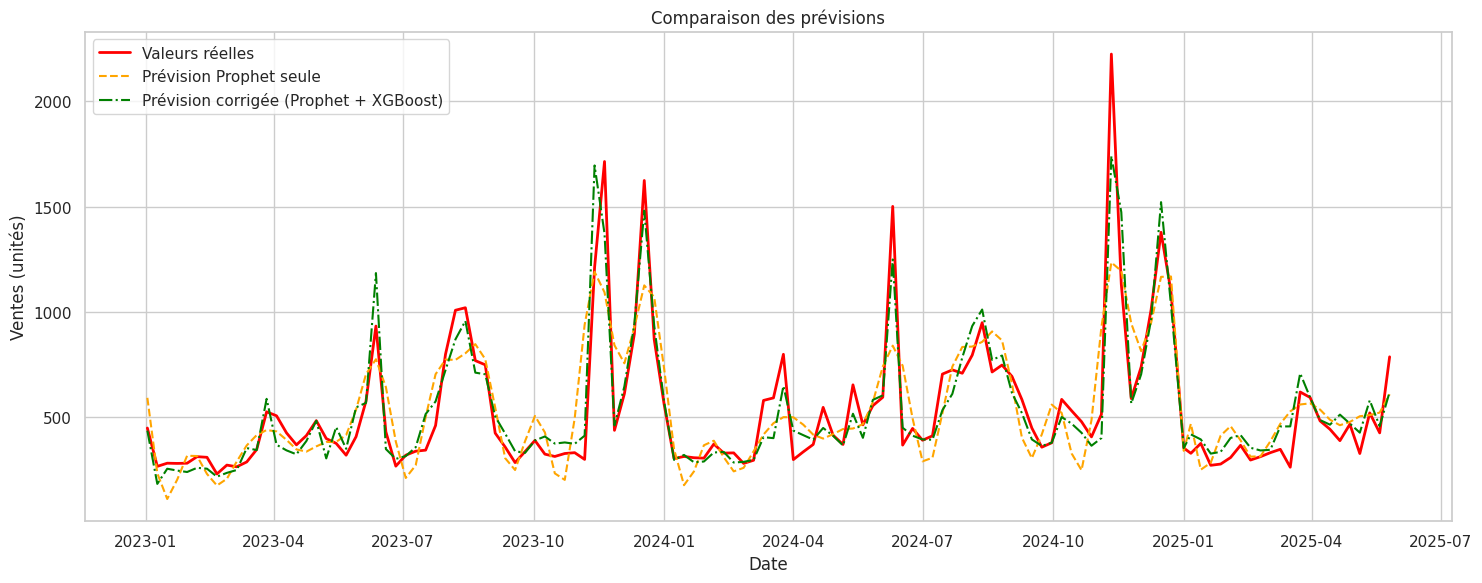

In [93]:

plot_df = forecast[forecast['y'].notna()]

plt.figure(figsize=(15, 6))
plt.plot(plot_df['ds'], plot_df['y'], label='Valeurs réelles', color='red', linewidth=2)
plt.plot(plot_df['ds'], plot_df['Predicted_Sales'], label='Prévision Prophet seule', color='orange', linestyle='--')
plt.plot(plot_df['ds'], plot_df['corrected_forecast_full'], label='Prévision corrigée (Prophet + XGBoost)', color='green', linestyle='-.')

plt.title("Comparaison des prévisions")
plt.xlabel("Date")
plt.ylabel("Ventes (unités)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


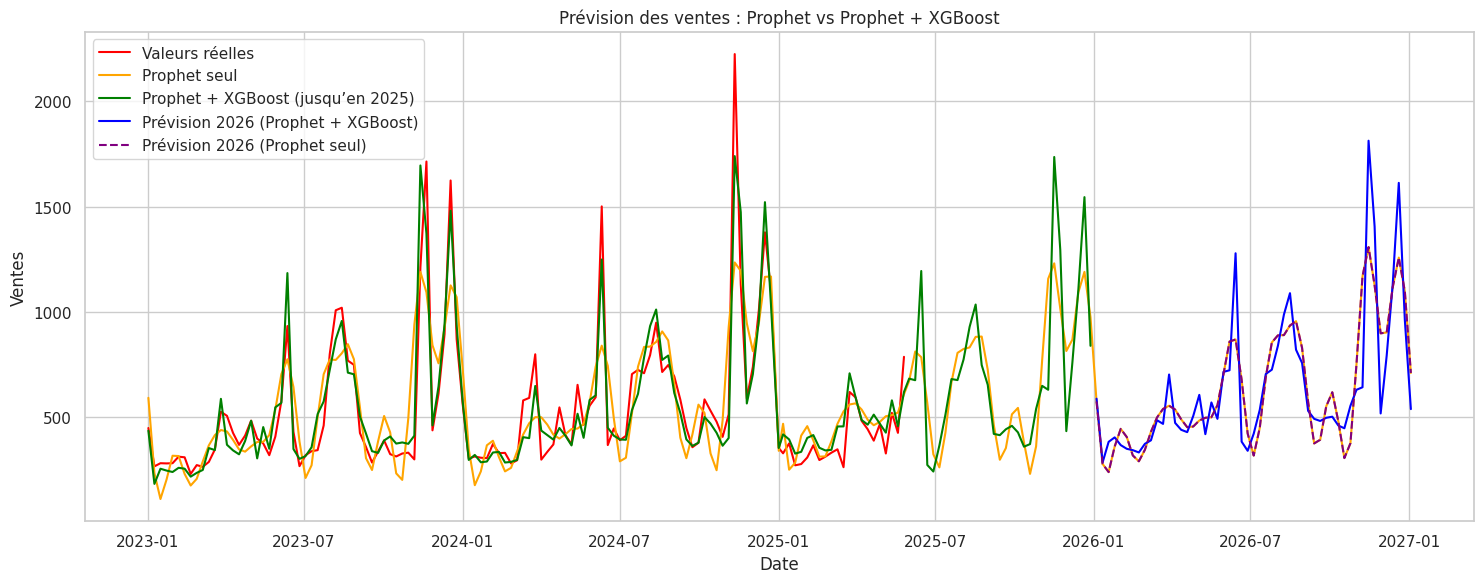

In [103]:

forecast['Prophet_only_2026'] = forecast['Predicted_Sales'].where(forecast['ds'].dt.year >= 2026)


plt.figure(figsize=(15, 6))

plt.plot(forecast['ds'], forecast['y'], label='Valeurs réelles', color='red')

plt.plot(forecast['ds'], forecast['Predicted_Sales'], label='Prophet seul', color='orange')

plt.plot(forecast[forecast['ds'].dt.year < 2026]['ds'],
         forecast[forecast['ds'].dt.year < 2026]['corrected_forecast_full'],
         label='Prophet + XGBoost (jusqu’en 2025)', color='green')


plt.plot(forecast[forecast['ds'].dt.year >= 2026]['ds'],
         forecast[forecast['ds'].dt.year >= 2026]['corrected_forecast_full'],
         label='Prévision 2026 (Prophet + XGBoost)', color='blue')

plt.plot(forecast['ds'], forecast['Prophet_only_2026'],
         label='Prévision 2026 (Prophet seul)', color='purple', linestyle='--')

plt.title("Prévision des ventes : Prophet vs Prophet + XGBoost")
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [104]:

predicted_all = forecast[forecast['ds'] <= '2026-12-31'][['ds', 'corrected_forecast_full', 'y', 'Predicted_Sales']].reset_index(drop=True)


import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

batch_size = 200
for start in range(0, len(predicted_all), batch_size):
    end = start + batch_size
    print(f"\n--- Lignes {start} à {end-1} ---")
    print(predicted_all.iloc[start:end])


pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')



--- Lignes 0 à 199 ---
            ds  corrected_forecast_full       y  Predicted_Sales
0   2023-01-02                   437.25  450.00           593.35
1   2023-01-09                   184.78  268.00           235.23
2   2023-01-16                   256.72  283.00           113.07
3   2023-01-23                   248.04  282.00           204.73
4   2023-01-30                   241.24  283.00           318.39
5   2023-02-06                   261.17  314.00           317.07
6   2023-02-13                   256.94  311.00           231.94
7   2023-02-20                   219.19  232.00           177.15
8   2023-02-27                   237.13  274.00           208.93
9   2023-03-06                   250.91  266.00           291.46
10  2023-03-13                   354.82  289.00           367.49
11  2023-03-20                   345.41  348.00           416.42
12  2023-03-27                   588.53  527.00           440.49
13  2023-04-03                   370.47  508.00           433.71
1



```
# Ce texte est au format code
```




**Prophet +XGBoost automated**
```





In [105]:
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import pandas as pd

def prophet_xgb_automated(data1, dept_id, n_weeks=84):
    results = []


    data_dept = data[data['Department'] == dept_id].copy()
    produits = data_dept[['Department', 'Category', 'Brand']].drop_duplicates()

    for _, row in produits.iterrows():
        dept, cat, brand = row['Department'], row['Category'], row['Brand']

        df = data_dept[
            (data_dept['Category'] == cat) &
            (data_dept['Brand'] == brand)
        ].copy()

        if df.empty:
            continue


        df['Date'] = pd.to_datetime(df['Date'])
        df = df.groupby('Date')['Sales (Units)'].sum().reset_index()
        df = df.rename(columns={'Date': 'ds', 'Sales (Units)': 'y'})
        df = df.sort_values('ds')

        if df['y'].sum() == 0 or len(df) < 20:
            continue


        model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
        model.fit(df)

        future = model.make_future_dataframe(periods=n_weeks, freq='W')
        forecast = model.predict(future)
        forecast = forecast.rename(columns={'yhat': 'Predicted_Sales'})


        df_residuals = df.set_index('ds')
        forecast_residuals = forecast.set_index('ds')
        residuals = df_residuals['y'] - forecast_residuals['Predicted_Sales']
        residuals = residuals.reset_index().rename(columns={0: 'residual'})
        forecast = forecast.reset_index()
        forecast = forecast.merge(residuals, on='ds', how='left')
        forecast = forecast.merge(df[['ds', 'y']], on='ds', how='left')


        forecast['dow'] = forecast['ds'].dt.dayofweek
        forecast['week'] = forecast['ds'].dt.isocalendar().week
        forecast['month'] = forecast['ds'].dt.month

        train_data = forecast[forecast['residual'].notna()]
        features = ['dow', 'week', 'month']

        if len(train_data) < 10:
            continue

        xgb_model = XGBRegressor()
        xgb_model.fit(train_data[features], train_data['residual'])

        forecast['residual_pred'] = xgb_model.predict(forecast[features])
        forecast['corrected_forecast'] = forecast['Predicted_Sales'] + forecast['residual'].fillna(forecast['residual_pred'])
        forecast['corrected_forecast_full'] = forecast['Predicted_Sales'] + forecast['residual_pred']

        forecast['corrected_forecast_full'] = forecast['corrected_forecast_full'].round().clip(lower=0).astype(int)
        forecast['Predicted_Sales'] = forecast['Predicted_Sales'].round().clip(lower=0).astype(int)


        forecast['Department'] = dept
        forecast['Category'] = cat
        forecast['Brand'] = brand

        results.append(forecast)

    if results:
        final_df = pd.concat(results).reset_index(drop=True)


        eval_set = final_df[final_df['y'].notna()]
        y_true = eval_set['y'].values
        y_pred = eval_set['corrected_forecast_full'].values
        mae = mean_absolute_error(y_true, y_pred)
        rmse = sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100

        def smape(y_true, y_pred):
          return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
        smape_val = smape(y_true, y_pred)
        print(f"Prophet + XGBoost for department {dept_id} → "
          f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape_val:.2f}%")


        return final_df
    else:
        print(f"Aucune prédiction générée pour le département {dept_id}.")
        return pd.DataFrame()


In [107]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)



forecast = prophet_xgb_automated(data1, dept_id=11)


required_cols = ['Category', 'Brand', 'Department', 'ds', 'y', 'Predicted_Sales', 'corrected_forecast_full']
for col in required_cols:
    assert col in forecast.columns, f"Colonne manquante : {col}"


pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)


display(forecast[required_cols].head(1000))


INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 20.
INFO:prophet:n_changepoints greater than number of observations. Using 16.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 21.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 21.
INFO:prophet:n_changepoints greater than number of observations. Using 21.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoin

Prophet + XGBoost for department 11 → MAE: 1.74 | RMSE: 6.75 | R²: 0.9327 | MAPE: 92740711261561744.00% | sMAPE: nan%


,Category,Brand,Department,ds,y,Predicted_Sales,corrected_forecast_full
0,110214,7460,11,2023-01-02,0.00,0,0
1,110214,7460,11,2023-01-09,0.00,0,0
2,110214,7460,11,2023-01-16,0.00,0,0
3,110214,7460,11,2023-01-23,0.00,0,0
4,110214,7460,11,2023-01-30,1.00,0,1
5,110214,7460,11,2023-02-06,0.00,0,0
6,110214,7460,11,2023-02-13,0.00,0,0
7,110214,7460,11,2023-02-20,0.00,0,0
8,110214,7460,11,2023-02-27,0.00,0,0
9,110214,7460,11,2023-03-06,0.00,0,0


In [108]:

cols_to_export = ['Category', 'Brand', 'Department', 'ds', 'y', 'Predicted_Sales', 'corrected_forecast_full']


forecast[cols_to_export].to_csv("forecast_dept.csv", index=False)

print("✅ Fichier 'forecast_dept.csv' enregistré avec succès.")


✅ Fichier 'forecast_dept.csv' enregistré avec succès.


In [109]:
from google.colab import files
files.download("forecast_dept.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>